## 1. Import Libraries and Load Data

Import all required libraries and load the processed dataset from a pickle file.

In [ ]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import math
import streamlit as st
import plotly.express as px


df = pd.read_csv('../data/activities.csv')


ModuleNotFoundError: No module named 'streamlit'

## 2. Inspect df and select rows with date_1 values

In [ ]:
print('The number of df columns with only NaN values in original df:')
print(len(df.columns[df.isnull().all()]))

# Remove columns with only NaN values
df =df.dropna(axis=1, how='all')

print("--------------------------------")
print('The number of df columns with only NaN values in cleaned df is:')
print(len(df.columns[df.isnull().all()]))

print("--------------------------------")
print('df columns are:')
print(list(df.columns))
print("")
print(f'original df shape is {df.shape}')

print("--------------------------------")
df["Afstand"] = pd.to_numeric(df["Afstand"], errors='coerce')
print(f'Afstand dtypes is:{df["Afstand"].dtypes}')

print(df[["Verstreken tijd", "Verstreken tijd.1", "Beweegtijd", "Gemiddelde snelheid", "Gemiddelde hartslag","Gemiddelde snelheid (op basis van verstreken tijd)", "Gemiddelde vergelijkbare tempo op vlak terrein"]].describe())



The number of df columns with only NaN values in original df:
30
--------------------------------
The number of df columns with only NaN values in cleaned df is:
0
--------------------------------
df columns are:
['Activiteits-ID', 'Datum van activiteit', 'Naam activiteit', 'Activiteitstype', 'Beschrijving van activiteit', 'Verstreken tijd', 'Afstand', 'Max. hartslag', 'Vergelijkbare poging', 'Woon-werkverkeer', 'Uitrusting voor activiteit', 'Bestandsnaam', 'Gewicht fiets', 'Verstreken tijd.1', 'Beweegtijd', 'Afstand.1', 'Max. snelheid', 'Gemiddelde snelheid', 'Totale stijging', 'Totale daling', 'Kleinste hoogte', 'Grootste hoogte', 'Max. stijgingspercentage', 'Gemiddeld stijgingspercentage', 'Max. cadans', 'Gemiddelde cadans', 'Max. hartslag.1', 'Gemiddelde hartslag', 'Gemiddeld wattage', 'Calorieën', 'Gemiddelde temperatuur', 'Vergelijkbare poging.1', 'Voorkeur voor ervaren inspanning', 'Woon-werkverkeer.1', 'Van upload', 'Aan stijgingspercentage aangepaste afstand', 'Tijd weerbeeld'

## 3. Clean Date feature

In [ ]:
months = {
    # volledige namen
    'januari': 'January',
    'februari': 'February',
    'maart': 'March',
    'april': 'April',
    'mei': 'May',
    'juni': 'June',
    'juli': 'July',
    'augustus': 'August',
    'september': 'September',
    'oktober': 'October',
    'november': 'November',
    'december': 'December',

    # afkortingen
    'jan': 'January',
    'feb': 'February',
    'mrt': 'March',
    'apr': 'April',
    'mei': 'May',
    'jun': 'June',
    'jul': 'July',
    'aug': 'August',
    'sep': 'September',
    'okt': 'October',
    'nov': 'November',
    'dec': 'December',
}

df['Datum van activiteit_en'] = df['Datum van activiteit'].str.lower()
for nl, en in months.items():
    df['Datum van activiteit_en'] = df['Datum van activiteit_en'].str.replace(nl, en, regex=False)

df['Datum van activiteit'] = pd.to_datetime(
    df['Datum van activiteit_en'],
    format='%d %B %Y, %H:%M:%S'
)

df.drop(columns='Datum van activiteit_en', inplace=True)
df = df[df['Afstand'] != 0]
df = df[df['Activiteitstype'] != 'Wandeling']


df['Datum van activiteit'] = pd.to_datetime(df['Datum van activiteit'])
df['Date']= df['Datum van activiteit']
df['Year'] = df['Datum van activiteit'].dt.year
df['Month'] =df['Datum van activiteit'].dt.month
df['Quarter']= df['Datum van activiteit'].dt.quarter
df['Week']=df['Datum van activiteit'].dt.isocalendar().week


print("--------------------------------")

print(f'Data were collected starting from:{df["Date"].min()}')


--------------------------------
Data were collected starting from:2017-04-15 08:20:08


## Check Features

In [ ]:
print(df['Beweegtijd'].describe())
print(df['Afstand.1'].describe())

count      877.000000
mean      4282.304447
std       3801.840927
min         43.000000
25%       2094.000000
50%       3109.000000
75%       4506.000000
max      34800.000000
Name: Beweegtijd, dtype: float64
count       877.000000
mean      23478.212657
std       28669.965556
min           0.500000
25%        6635.100000
50%       10469.200000
75%       30661.800000
max      188727.500000
Name: Afstand.1, dtype: float64


## 3. Explore 2025 df

C:\Users\jasmi\AppData\Local\Temp\ipykernel_35404\1553693608.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Month'] = df_2025['Date'].dt.month_name()
C:\Users\jasmi\AppData\Local\Temp\ipykernel_35404\1553693608.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2025['Month'] = df_2025['Month'].astype(month_cat)
C:\Users\jasmi\AppData\Local\Temp\ipykernel_35404\1553693608.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pa

The nbr of Rows with zero Beweegtijd:
0
The nbr of Rows with zero Hours:
0
     Activiteits-ID Datum van activiteit     Naam activiteit Activiteitstype  \
911     16801682405  2025-12-21 06:32:53          Ochtendrit        Fietsrit   
912     16808174546  2025-12-22 05:55:35   Ochtendzwemsessie         Zwemmen   
913     16810066563  2025-12-22 10:49:45          Middagloop  Hardloopsessie   
914     16819954263  2025-12-23 12:01:03         Namiddagrit        Fietsrit   
915     16835924453  2025-12-25 10:07:24          Middagloop  Hardloopsessie   
916     16845565136  2025-12-26 14:32:48        Namiddagloop  Hardloopsessie   
917     16853568853  2025-12-27 08:23:35       KOTK Cis4ever        Fietsrit   
918     16855124454  2025-12-27 14:10:09  Namiddagzwemsessie         Zwemmen   
919     16871256203  2025-12-29 07:54:23         Ochtendloop  Hardloopsessie   
920     16887803566  2025-12-30 19:04:48     Avondzwemsessie         Zwemmen   

    Beschrijving van activiteit  Verstreken 

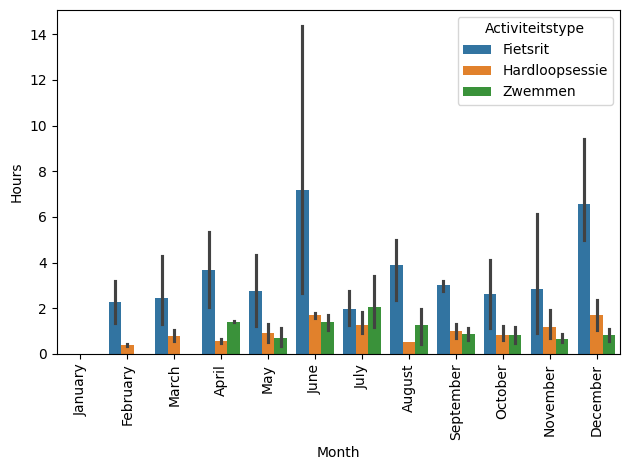

In [ ]:
from pandas.api.types import CategoricalDtype

# Count the number of activities per year
df_2025 = df[df['Year'] == 2025]
df_2025['Month'] = df_2025['Date'].dt.month_name()

month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December']

month_cat = CategoricalDtype(categories=month_order, ordered=True)
df_2025['Month'] = df_2025['Month'].astype(month_cat)

df_weekly = (
    df_2025
    .groupby(['Month', 'Week', 'Activiteitstype'], observed=True,as_index=False)
    ['Beweegtijd']
    .sum())

# convert seconds → hours
df_weekly['Hours'] = df_weekly['Beweegtijd'] / 3600

monthly_avg = (
    df_weekly
    .groupby(['Month', 'Activiteitstype'], as_index=False)
    ['Hours']
    .mean())

sns.barplot(data=df_weekly, x='Month', y='Hours', hue='Activiteitstype')
plt.xticks(rotation=90)  #90 degrees
plt.tight_layout()

nbr_zero_beweegtijd = df_weekly[df_weekly['Beweegtijd'] == 0].shape[0]
nbr_zero_hours = df_weekly[df_weekly['Hours'] == 0].shape[0]
print('The nbr of Rows with zero Beweegtijd:')
print(nbr_zero_beweegtijd)
print('The nbr of Rows with zero Hours:')
print(nbr_zero_hours)

print(df_2025.tail(10))
print(df_weekly[df_weekly['Month']=='December'])


In [ ]:
print(df_2025[df_2025['Month']==1])

Empty DataFrame
Columns: [Activiteits-ID, Datum van activiteit, Naam activiteit, Activiteitstype, Beschrijving van activiteit, Verstreken tijd, Afstand, Max. hartslag, Vergelijkbare poging, Woon-werkverkeer, Uitrusting voor activiteit, Bestandsnaam, Gewicht fiets, Verstreken tijd.1, Beweegtijd, Afstand.1, Max. snelheid, Gemiddelde snelheid, Totale stijging, Totale daling, Kleinste hoogte, Grootste hoogte, Max. stijgingspercentage, Gemiddeld stijgingspercentage, Max. cadans, Gemiddelde cadans, Max. hartslag.1, Gemiddelde hartslag, Gemiddeld wattage, Calorieën, Gemiddelde temperatuur, Vergelijkbare poging.1, Voorkeur voor ervaren inspanning, Woon-werkverkeer.1, Van upload, Aan stijgingspercentage aangepaste afstand, Tijd weerbeeld, Weersomstandigheden, Buitentemperatuur, Gevoelstemperatuur, Dauwpunt, Vochtigheid, Luchtdruk, Windsnelheid, Windstoot, Windrichting, Neerslagintensiteit, Tijd zonsopgang, Tijd zonsondergang, Maanstand, Uitrusting, Kans op neerslag, Type neerslag, Bewolking, Zi

In [ ]:
dec_week7 = df_2025[(df_2025['Month'] == 'December') & (df_2025['Week'] == 52)]
print(dec_week7[['Date', 'Week', 'Year', 'Datum van activiteit']])

                   Date  Week  Year Datum van activiteit
912 2025-12-22 05:55:35    52  2025  2025-12-22 05:55:35
913 2025-12-22 10:49:45    52  2025  2025-12-22 10:49:45
914 2025-12-23 12:01:03    52  2025  2025-12-23 12:01:03
915 2025-12-25 10:07:24    52  2025  2025-12-25 10:07:24
916 2025-12-26 14:32:48    52  2025  2025-12-26 14:32:48
917 2025-12-27 08:23:35    52  2025  2025-12-27 08:23:35
918 2025-12-27 14:10:09    52  2025  2025-12-27 14:10:09


## 4. Show Weekly acitivity time

In [ ]:
fig = px.bar(df_weekly, x="Week", y="Hours", color="Activiteitstype")
st.plotly_chart(fig, use_container_width=True)
fig.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="category"
    )
)

